# <u>Math 9 Final Project, Data Science/Analysis - Eric Ross</u> 
## Topic: Sector Contribution to a Country's GDP (%) involving 208 countries from 1960-2024.
### Sources: https://docs.google.com/document/d/15foeU5uOuPJPPBwRJ7ctUe8pzwfdmSQTPhgHzzw-C_w/edit?usp=sharing


#### <u>Context for Topic:</u>

GDP stands for Gross Domestic Product, which represents the total value of goods and services produced by a country. It is used as an indicator for an economy's performance. A country's GDP can be attributed to different sectors, such as Industry, Manufacturing, Agriculture, etc. From the source, "Worldbankdata", we analyze information of each sectors contribution (in percentage) to its country's GDP from 1960 to 2024. We do this for 208 countries. The goal is to make different observations on economic change over time on a global scale.

__What questions do we look to answer?__

* How does one sector's growth over time affect another sectors growth over time within one chosen country?
* How does one sector grow over time within one chosen country?
* How does one sector compare across two countries over time?
* What is the average growth for each sector across all countries over time?


#### <u>Plan of Action:</u>

__First, what data is necessary for my project?__ (Gathered from observing the csv.file in excel)

* Country name hiphenated which corresponds to the column, "REF_AREA"
* Full country name, "REF_AREA_LABEL"
* Sector name which corresponds to the column, "INDICATOR"
* Year(s) which corresponds to the column, "TIME_PERIOD"
* Contribution to GDP in % which corresponds to the column, "OBS_VALUE"
* Every row for each country (This corresponds to a different year).

__What must be done to gather the data cleanly?__

* Ensure that there are no missing values that might cause errors. Look into filling missing values if needed. This goes with ensuring size or number of inputs will not cause errors (There may be some missing data, if not, try creating safety measures anyway since its good practice).
* Create some form of sorting for the data (Alphabetical for countries, numerically ascending/descending for GDP %, etc.).
* Also, create some form of interactive function that allows user to pick specific countries, sectors, or times easily (Similar to Midterm)
* Check data types to ensure that different types (float, int64, etc.) aren't going to hinder any processes (seaborn, matplotlib, etc.). If it is, find a way to make it work.
* Finally, only gather relevant data. If there are any other problems or errors, debug.

__What must be done to connect the data to my questions?__

* Think of some kind of indexing. I need to be able to pull on data from these charts to make conclusions. This will involve indexing of some form
* Create separate functions. Separate functions will allow me to find each solution and display it cleanly
* Research what math or operations must happen to solve these questions
* Research how to demonstrate findings after operations in a graph/visualization
* Draw conclusions
&nbsp;

# <u>Code:</u>

<u>Imports:</u> Created my own kernel called "Math9FinalProject" with Python 3.11 (Current industry standard) for practice.

In [32]:
import numpy as np #Used for mathematical computing and arrays
import pandas as pd #One of the main packages for data cleaning and file importing.
import matplotlib.pyplot as plt #Imports tools for multiple graphs/visualizations
import seaborn as sns #Similar to matplotlib in that it helps create visualizations
import statistics as statistics #Imports statistics tools like mean or min.
import ipywidgets as widgets #Imports widgets such as dropdown menus in this case.
from IPython.display import display #Imports display for widgets in Jupyter.
from ipywidgets import interact #Interact is used to create interactive widgets for functions
import sys #Imports sys which gives access to system information
#print(sys.executable) #Checks what environment is being run.

<u>Cleaning, Grouping, and Sorting Data:</u> Reads files, cleans the data, and then compiles it into one large dataframe. 

In [33]:
All_Sector_Files = ["Industry_Data.csv", "Agriculture_Data.csv", "Manufacturing_Data.csv", "Services_Data.csv", "Trading_Data.csv", "Export_Data.csv",
                    "Import_Data.csv"] 
#Stores the different sectors in a list. More efficient for reading multiple files. ChatGPT as a reference here. I needed clarification on whether I 
#should use a numpy array or not. However, I knew that I'd be storing an array or list.

Cleaned_Df = [] #Creating a place to store the cleaned data frames for each sector

Sectors = [] #Storing sector names in a list for later.

for x in All_Sector_Files: #for loop iterates through each csv.file (each sector).    

    Indicator_Name = x.replace("_Data.csv","") #Creates a nice sector name using csv.file through ".replace command". ChatGPT and 
    #pandas website for reference. Used to see code syntax (replace tool). This was my idea though.
    
    Df = pd.read_csv(x) #Reads the csv.file and stores in Df. Df (or df) is the standard variable name since read_csv returns a pandas.DataFrame object. 
                        #ChatGPT and Pandas website (from lecture) for reference. ChatGPT taught me Df (or df) is standard and the Pandas website taught 
                        #me about how read_csv works. 
    
    #print(Df.columns) I had used the command earlier but this is very useful for loc. Shows column headers.
    
    Df = Df.loc[:,["REF_AREA","REF_AREA_LABEL","TIME_PERIOD", "INDICATOR", "OBS_VALUE"]] #loc command "pulls" out rows or columns based on literal name.
    #Here, it pulls out all rows and the important columns. Reference: Professor Luke Smith office hours, I was told that iloc and loc would be useful.
    
    Df["INDICATOR"] = Indicator_Name #Changes rows of "INDICATOR" column to sector name. 
    #Ensures that there are no different rows (Agriculture vs AGRICULTURE for example).

    Sectors.append(Indicator_Name) #Appends the current iteration's improved indicator (Sector indicator) name to Sectors.
    
    Df = Df.dropna(subset=["REF_AREA","REF_AREA_LABEL","TIME_PERIOD", "INDICATOR","OBS_VALUE"]) #Removes rows with missing values in columns
    Df = Df.drop_duplicates() #Removes duplicate rows.

    Cleaned_Df.append(Df) #The for loop cleans one file at a time. Once a file is done, the cleaned data frame is added to Cleaned_Df using ".append".

Merged_Df = pd.concat(Cleaned_Df, ignore_index = True) #Merges all cleaned dataframes in Cleaned_Df using ".concat". It ignores indexes using 
# "ignore_index = True". This ensures that indexes line up nicely (Otherwise, it would be 0 1 0 1 for example)

Merged_Df = Merged_Df.rename(columns={"REF_AREA":"Country_Code","OBS_VALUE":"GDP(%)","TIME_PERIOD":"Year","INDICATOR":"Sector","REF_AREA_LABEL":"Country_Name"}) 
#Renames the column headers to make it easier to understand. 

Merged_Df = Merged_Df.sort_values(by=["Country_Code","Year", "Sector"],ascending=[True, False,True]).reset_index(drop=True) 
#Sorts alphabetically or numerically with ".sort_values".Boolean determines whether ascending or not. 
# ".reset_index resets each index after sorting (0 1 0 1 becomes 0 1 2 3). Keeps dataframe clean.

Merged_Df["Sector"] = Merged_Df["Sector"].str.replace(r'[^a-zA-Z\s]+', '', regex=True) #Removes any special characters or symbols from the sector names.
#Ensures Agriculture~ is cleaned for example.

Merged_Df.columns = Merged_Df.columns.str.strip().str.upper().str.replace(" ","_") #Strips space from front and back of column headers, converts headers
# to uppercase. Replaces spaces in between with underscores.

Merged_Df["GDP(%)"] = pd.to_numeric(Merged_Df["GDP(%)"]).astype("float64") #Ensures GDP value is a float
Merged_Df["YEAR"] = pd.to_numeric(Merged_Df["YEAR"]).astype("int64") #Ensures Year value is an integer

Merged_Df = Merged_Df.round({"GDP(%)": 4}) #Rounds GDP float to 3 decimal places

Merged_Df[["COUNTRY_CODE","COUNTRY_NAME","SECTOR"]] = Merged_Df[["COUNTRY_CODE", "COUNTRY_NAME", "SECTOR"]].astype("category") #Stores as categories.
#Saves memory by storing each as a 0 1 2 ... instead of a full string. For example, United States might be repeated a lot. Instead of reading as string,
#it might assign 1 to United States.

<u> Creating/Finalizing Data to Pull From:</u> Creates a dataframe ready for graphing with pivot, makes copies, and sets up for widgets.

In [34]:
Pivoted_Data_Frame = Merged_Df.pivot_table(values="GDP(%)", index = ["COUNTRY_CODE", "COUNTRY_NAME", "YEAR"], columns = "SECTOR").reset_index()
#pivot_table command takes values from GDP(%) column and places it underneath its corresponding sector. The sectors are shown along the column header.
#Then the index values are shown along the rows, in this case it represents country code, name, and year. This creates a format for us to plot. 

Wide_Df = Pivoted_Data_Frame.copy() #Creates a copy of original pivot table since operations might change data frame.

Country_List = sorted(Wide_Df["COUNTRY_NAME"].dropna().unique().tolist()) #Pulls the country column out of pivoted data frame. It removes missing values
#, only grabs unique values (one country name repeats many times), and converts the pandas array into a python list. "sorted()" sorts the names 
#alphabetically. We use this list for widgets.

Sector_List = ["Agriculture", "Industry", "Manufacturing", "Services", "Trading", "Export", "Import"] #List of all sectors. We use this list for widgets.

#  _Data Visualization and Graph Section_

## Correlation between Two Sectors in a Chosen Country

In [35]:
def analyze_sector_relationship(country, sector_1, sector_2): #Defines function with inputs

    Country_Df = Wide_Df[Wide_Df["COUNTRY_NAME"] == country].copy() #Filters the dataset and stores only the selected country values in another dataframe.
    Country_Df = Country_Df.sort_values("YEAR"); #Sorts rows in Country_Df by year using ".sort_values"
    
    if sector_1 == sector_2: #If both sectors chosen are the same, then print message.
        print("Choose two different sectors.")
        return #Restarts function.
    #Important since we want to compare two different sectors. Also, keeps from error coding.
    
    Country_Df = Country_Df.dropna(subset=[sector_1, sector_2]) #Removes sectors with missing values
    
    if Country_Df.empty: #If there is no data for the country selected, print message
        print("No data available for this selection.") 
        return #Restarts function
    #Important because some countries might not have as much data collected.
    
    correlation_value = Country_Df[sector_1].corr(Country_Df[sector_2]) #Calculates the correlation value between the two chosen sectors using ".corr"
    
    print(f"Country: {country}") #Prints the selected country name
    print(f"Observed Sector: {sector_1}") #Prints sector that is being observed. (As observed sector grows, how does compared sector react)
    print(f"Compared Sector: {sector_2}") #Prints the sector being compared.
    print(f"Correlation over time: {correlation_value:.3f}") #Prints the correlation value between the two sectors with a float up to 3 decimals

    Slope, Intercept = np.polyfit(Country_Df[sector_1], Country_Df[sector_2],1) #Creates a regression line. Regression lines show correlation.
    x_values = np.array([Country_Df[sector_1].min(), Country_Df[sector_1].max()]) #x values
    y_values = Slope*x_values + Intercept #y values

    print(f"Regression slope: {Slope:.4f}") #Displays the regression lines slope value with a float of up to 4 decimals.

    plt.figure(figsize=(8, 6)) #Creating a figure
    plt.scatter(Country_Df[sector_1], Country_Df[sector_2]) #Creating a scatter plot with sector 1 as x and sector 2 as y (correlation)
    
    plt.plot(x_values,y_values,label="Regression Line") #Plotting regression line

    plt.title(f"{sector_1} vs {sector_2} in {country}") #Title
    plt.xlabel(sector_1) #x axis label
    plt.ylabel(sector_2) #y axis label
    plt.legend() #Adding a legend
    plt.grid(True) #Creating gridlines
        
interact(analyze_sector_relationship, country=widgets.Dropdown(options=Country_List, description="Country"),
         sector_1=widgets.Dropdown(options=Sector_List, description="Sector 1"),
         sector_2=widgets.Dropdown(options=Sector_List, description="Sector 2"));
#Interact command links its selected values to function. Creating a dropdown named country with our earlier python list with all the countries. 
#Then it creates a dropdown menu for sector 1 and sector 2 using the sector list from earlier.


plt.show() #Shows plot
plt.tight_layout() #Cleans layout

interactive(children=(Dropdown(description='Country', options=('Afghanistan', 'Africa Eastern and Southern', '…

<Figure size 640x480 with 0 Axes>

#### How it works?

__Points/axes:__ The scatterplot compares two chosen sectors (pulled from dropdown menu) within one chosen country (pulled from downdown menu) from 1960-2024. The x-axis represents the first chosen sector's contribution as a percent value. The y-axis represents the other chosen sector's contribution as a percent value. Each point corresponds to one year of data for the chosen country. It is important to note that one point does represents both sectors values (MAKE SURE TO LOOK AT X AXIS AND Y AXIS FOR THE VALUES). The reason that many points may not display is due to lack of data for the country or one/both sectors. Also, there is a slight chance of overlapping points due to close values.

__Linear Regression Line:__ The figure includes a linear regression line to show the general behavior of the compared sector as the observed sector grows. The linear regression line's slope approximates how much the compared sector contribution changes as the observed sector contribution increases by 1%.

__Correlation Value:__ The correlation value between the two sectors is calculated to see the strength of their linear relationship. 
* A value of 1 means they grow together.
* A value of -1 means that as the observed sector grows, the compared sector shrinks.
* A value of 0 means they have no relationship

#### What can we gather?

The points let us see two sector contribution values at the same time for each year (unless no data). This is already useful since we can see which sector was stronger that year by looking at 

&nbsp;

## Chosen Sector's Growth Over Time in a Chosen Country

In [36]:
def analyze_single_sector_over_time(country, sector): #Defines function

    
    Country_Df = Wide_Df[Wide_Df["COUNTRY_NAME"] == country].copy() #Filters for country, creates another dataset with country values. Renames
    #COUNTRY_NAME to country.
    
    Country_Df = Country_Df.sort_values("YEAR") #Sorts rows in Country_Df by year using ".sort_values"
    
    Country_Df = Country_Df.dropna(subset=[sector]) #Drops all missing values in sector column 

    if Country_Df.empty: #If the country selected has no data, print no data
        print("No data available for this selection.")
        return

    start_year = Country_Df["YEAR"].iloc[0] #Selects the first index of the YEAR column in Country_Df
    end_year = Country_Df["YEAR"].iloc[-1] #Selects the last index of the Year column in Country_Df

    start_value = Country_Df[sector].iloc[0] #Selects the first index of the sector column in Country_Df
    end_value = Country_Df[sector].iloc[-1] #Selects the last index of the sector column in Country_Df

    absolute_change = end_value - start_value #

    if start_value != 0:
        percent_change = ((end_value - start_value) / abs(start_value)) * 100
    else:
        percent_change = np.nan

    slope, intercept = np.polyfit(Country_Df["YEAR"], Country_Df[sector], 1)
    trend_line = slope * Country_Df["YEAR"] + intercept
    
    print(f"Country: {country}")
    print(f"Sector: {sector}")
    print(f"Start year: {start_year}")
    print(f"End year: {end_year}")
    print(f"Start value: {start_value:.3f}")
    print(f"End value: {end_value:.3f}")
    print(f"Absolute change: {absolute_change:.3f}")
    print(f"Percent change: {percent_change:.3f}%")
    print(f"Trend slope per year: {slope:.4f}")
    plt.figure(figsize=(11, 6))
    plt.plot(Country_Df["YEAR"], Country_Df[sector], marker="o", label=f"{sector} Actual")
    plt.plot(Country_Df["YEAR"], trend_line, label="Trend Line")
    plt.title(f"{sector} Over Time in {country}")
    plt.xlabel("Year")
    plt.ylabel("GDP Contribution (%)")
    plt.grid(True)
    plt.legend()
    plt.show()
    
interact(analyze_single_sector_over_time, country=widgets.Dropdown(options=Country_List, description="Country"),
         sector=widgets.Dropdown(options=Sector_List, description="Sector"));

plt.tight_layout()
plt.show()

interactive(children=(Dropdown(description='Country', options=('Afghanistan', 'Africa Eastern and Southern', '…

<Figure size 640x480 with 0 Axes>

In [37]:
def analyze_sector_over_time_between_two_countries(Country_1, Country_2, sector):

    Country_1_Df = Wide_Df[Wide_Df["COUNTRY_NAME"] == Country_1].copy()
    Country_2_Df = Wide_Df[Wide_Df["COUNTRY_NAME"] == Country_2].copy()
    
    Country_1_Df = Country_1_Df.sort_values("YEAR")
    Country_2_Df = Country_2_Df.sort_values("YEAR")
    
    Country_1_Df = Country_1_Df.dropna(subset=[sector])
    Country_2_Df = Country_2_Df.dropna(subset=[sector])

    if Country_1 == Country_2:
        print("Choose two different countries.")
        return

    if Country_1_Df.empty or Country_2_Df.empty:
        print("No data available for this selection.")
        return

    Slope_1, Intercept_1 = np.polyfit(Country_1_Df["YEAR"], Country_1_Df[sector], 1)
    Slope_2, Intercept_2 = np.polyfit(Country_2_Df["YEAR"], Country_2_Df[sector], 1)

    Trend_Line_1 = Slope_1 * Country_1_Df["YEAR"] + Intercept_1
    Trend_Line_2 = Slope_2 * Country_2_Df["YEAR"] + Intercept_2

    print(f"Sector: {sector}")
    print(f"{Country_1} linear trend slope per year: {Slope_1:.4f}")
    print(f"{Country_2} linear trend slope per year: {Slope_2:.4f}")

    plt.figure(figsize=(11,6))
    plt.plot(Country_1_Df["YEAR"], Country_1_Df[sector], marker="o", label = f"{Country_1} Actual")
    #plt.plot(Country_1_Df["YEAR"], Trend_Line_1, label=f"{Country_1} Trend Line")

    plt.plot(Country_2_Df["YEAR"], Country_2_Df[sector], marker="o", label = f"{Country_2} Actual")
    #plt.plot(Country_2_Df["YEAR"], Trend_Line_2, label=f"{Country_2} Trend Line")

    plt.title(f"{sector} Over Time: {Country_1} vs {Country_2}")
    plt.xlabel("Year")
    plt.ylabel("GDP Contribution (%)")
    plt.grid(True)
    plt.legend()
    plt.show()

interact(analyze_sector_over_time_between_two_countries,
    Country_1=widgets.Dropdown(options=Country_List, description="Country 1"),
    Country_2=widgets.Dropdown(options=Country_List, description="Country 2"),
    sector=widgets.Dropdown(options=Sector_List, description="Sector"));

interactive(children=(Dropdown(description='Country 1', options=('Afghanistan', 'Africa Eastern and Southern',…

# Global Average for Sector Across All Countries

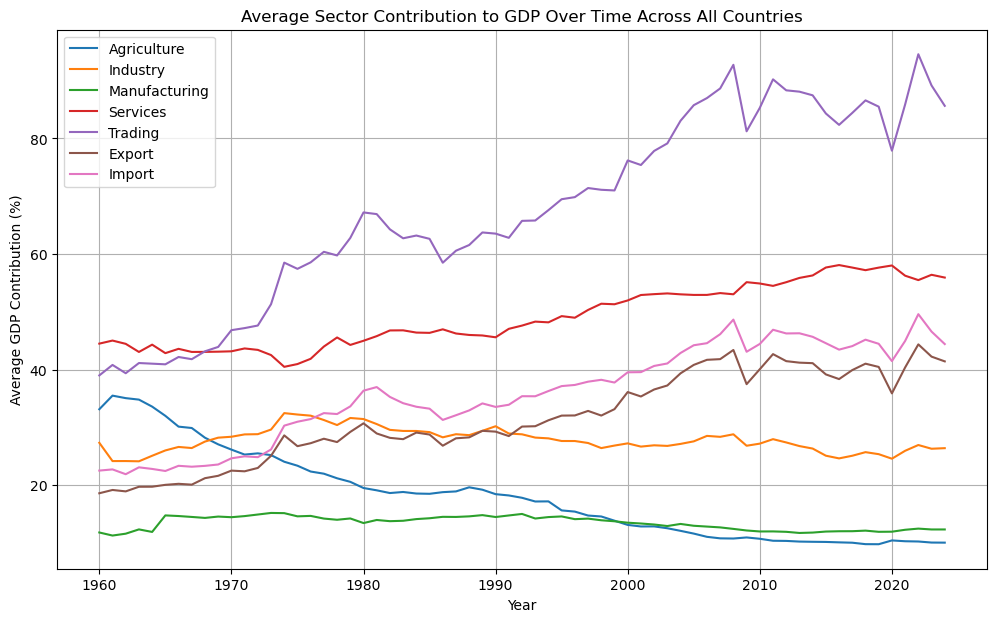

In [38]:
Global_Sector_Df = Wide_Df.groupby("YEAR")[Sector_List].mean()

plt.figure(figsize=(12, 7))
for sector in Sector_List:
    plt.plot(Global_Sector_Df.index, Global_Sector_Df[sector], label=sector)

plt.title("Average Sector Contribution to GDP Over Time Across All Countries")
plt.xlabel("Year")
plt.ylabel("Average GDP Contribution (%)")
plt.grid(True)
plt.legend()
plt.show()

In [39]:
#print(Sectors)
#print(Wide_Df.columns)
#Merged_Df = Merged_Df.drop(columns = ["INDICATOR"])
print(Merged_Df.size)
#print(Merged_Df.columns)
#print(Merged_Df.dtypes)
#print(Pivoted_Data_Frame.head())
#print(Correlation_Table.columns)
#print(Correlation_Table.dtypes)

378785


In [40]:
#print(Cleaned_Df)
#print(Merged_Df)
#print(Merged_Df.head())
#print(Merged_Df.columns)
#print(Merged_Df["Sector"].unique())
#print(Merged_Df.dtypes)
#print(Merged_Df.describe())
#print(Merged_Df["Sector"].value_counts())
#print(Merged_Df["Country Code"].nunique())
#print(Merged_Df["Year"].min())
#print(Merged_Df["Year"].max())
#print(Merged_Df.loc[Merged_Df["GDP(%)"] == Merged_Df["GDP(%)"].max()])
#Merged_Df.groupby("Sector").agg({"Country Code": "nunique","Year": ["min", "max", "nunique"]})
#Merged_Df.groupby("Sector")["GDP(%)"].describe()

In [41]:
#Df.columns = Df.columns.str.strip() #Strips the space from the front and back of the columns
    #Df.columns = Df.columns.str.upper()
#Merged_Df["COUNTRY_NAME"] = Merged_Df["COUNTRY_NAME"].astype("category")
#Merged_Df["SECTOR"] = Merged_Df["SECTOR"].astype("category")